# UBS no mapa: onde estão as unidades básicas — e o que o cadastro esconde

**Pergunta que este notebook responde:** onde ficam as Unidades Básicas de
Saúde do meu estado, quantas existem por habitante, e o que falta no cadastro?

**Fonte:** cadastro nacional de UBS do CNES, publicado pelo Ministério da
Saúde. **47.910 unidades**, com endereço e coordenadas.
**Tempo estimado:** 4 a 7 minutos.

> Este é o único exemplo do repositório em que a função `to_geojson()` da PySUS
> tem serventia — e mesmo aqui ela tem uma armadilha que o passo 5 mostra.

## Preparação

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"    # sigla do estado

## Passo 1 — Duas portas, uma estável

A mesma base tem duas entradas: uma **API REST**, que pagina por deslocamento
de linha, e um **arquivo CSV** publicado direto em armazenamento público.

Sempre que existir o arquivo, prefira o arquivo. A API paginada tem que ser
percorrida em dezenas de requisições cujo resultado pode variar entre passadas;
o arquivo vem inteiro, de uma vez, igual para todo mundo.

In [4]:
import io
import zipfile
import httpx
import pandas as pd

URL = ("https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/"
       "CNES/Unidades_Basicas_Saude-UBS_csv.zip")

with httpx.Client(timeout=300, follow_redirects=True) as cliente:
    resposta = cliente.get(URL)
resposta.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resposta.content)) as arquivo:
    interno = arquivo.namelist()[0]
    # A URL nao tem versao: ela sempre devolve "o mais recente". Quem le o
    # resultado daqui a seis meses nao tem como saber de quando era o retrato.
    # O carimbo de tempo do arquivo DENTRO do zip e a unica procedencia que o
    # proprio download carrega — entao guardamos ela e a levamos ao grafico.
    d = arquivo.getinfo(interno).date_time
    DATA_UBS = f"{d[2]:02d}/{d[1]:02d}/{d[0]}"
    ubs = pd.read_csv(io.BytesIO(arquivo.read(interno)), sep=";", low_memory=False)

print(f"Extração publicada em {DATA_UBS} (data do arquivo dentro do zip)")
print(f"{len(ubs):,} unidades básicas de saúde")
print(f"Colunas: {list(ubs.columns)}")
print(f"Municípios com pelo menos uma UBS: {ubs['IBGE'].nunique():,}")

Extração publicada em 29/08/2026 (data do arquivo dentro do zip)
47,920 unidades básicas de saúde
Colunas: ['CNES', 'UF', 'IBGE', 'NOME', 'LOGRADOURO', 'BAIRRO', 'LATITUDE', 'LONGITUDE']
Municípios com pelo menos uma UBS: 5,489


## Passo 2 — As coordenadas vêm com vírgula decimal

`LATITUDE` e `LONGITUDE` chegam como texto, e no mesmo arquivo convivem o ponto
e a vírgula como separador decimal. Lidas sem tratamento viram texto ou `NaN`,
e o mapa sai vazio sem nenhum erro.

In [5]:
print("Como vem do arquivo:")
print(ubs[["NOME", "LATITUDE", "LONGITUDE"]].head(3).to_string(index=False))

for coluna in ("LATITUDE", "LONGITUDE"):
    ubs[coluna] = pd.to_numeric(
        ubs[coluna].astype(str).str.replace(",", "."), errors="coerce")

validas = ubs["LATITUDE"].notna() & ubs["LONGITUDE"].notna()
print(f"\nCom coordenada utilizável: {validas.sum():,} de {len(ubs):,} "
      f"({validas.mean() * 100:.1f}%)")
print(f"Sem coordenada:            {(~validas).sum():,}")

Como vem do arquivo:
                            NOME   LATITUDE      LONGITUDE
CENTRO DE SAUDE JARDIM MONTANHES -19.911503 -43,9914089036
    UBS FRANCISCO VIEIRA DE MELO  -8.705590 -35,5995386839
               USF SANTO ESTEVAO  -8.218112    -35,2294359
Com coordenada utilizável: 45,997 de 47,920 (96.0%)
Sem coordenada:            1,923


## Passo 3 — O retângulo ingênuo do Brasil deixa Noronha de fora

A conferência de coordenada mais comum é "está dentro do retângulo do Brasil?".
Ela reprova unidades que estão certas: o país tem território a leste do
continente.

In [6]:
RETANGULO = dict(lat=(-34, 6), lon=(-74, -34))   # o retângulo "de sempre"

dentro = (ubs["LATITUDE"].between(*RETANGULO["lat"])
          & ubs["LONGITUDE"].between(*RETANGULO["lon"]))
suspeitas = ubs[validas & ~dentro]

print(f"Reprovadas pelo retângulo: {len(suspeitas)}")
print(suspeitas[["CNES", "UF", "IBGE", "NOME", "LATITUDE", "LONGITUDE"]]
      .to_string(index=False))
print("\nO código 260545 é Fernando de Noronha (PE), arquipélago no oceano")
print("a leste do continente. As três unidades existem e estão no lugar")
print("certo — quem confia no retângulo joga fora dados bons.")

Reprovadas pelo retângulo: 3
   CNES  UF   IBGE                                       NOME  LATITUDE  LONGITUDE
2429594  26 260545                  AMBULATORIO SANTO ANTONIO -3.845971 -32.410591
4353188  26 260545 UNIDADE DE SAUDE DA FAMILIA DOIS IRMAOS II -3.847577 -32.414550
3978109  26 260545    UNIDADE DE SAUDE DA FAMILIA DOIS IRMAOS -3.847673 -32.414474
O código 260545 é Fernando de Noronha (PE), arquipélago no oceano
a leste do continente. As três unidades existem e estão no lugar
certo — quem confia no retângulo joga fora dados bons.


## Passo 4 — O mapa do estado

Sem biblioteca de mapas: o próprio conjunto de pontos desenha o contorno do
estado. Cada ponto é uma UBS.

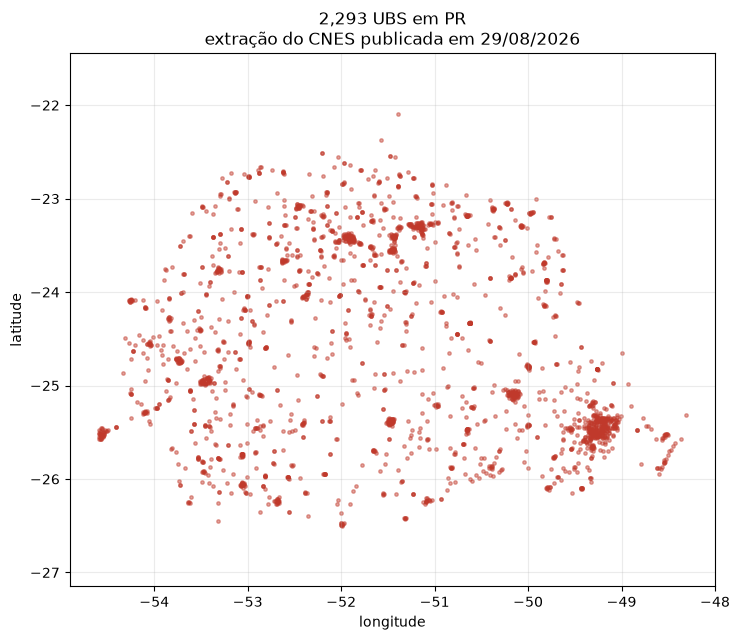

UBS em PR: 2,293 com coordenada, em 389 municípios


In [7]:
import matplotlib.pyplot as plt

CODIGO_UF = {
    "RO": 11, "AC": 12, "AM": 13, "RR": 14, "PA": 15, "AP": 16, "TO": 17,
    "MA": 21, "PI": 22, "CE": 23, "RN": 24, "PB": 25, "PE": 26, "AL": 27,
    "SE": 28, "BA": 29, "MG": 31, "ES": 32, "RJ": 33, "SP": 35,
    "PR": 41, "SC": 42, "RS": 43, "MS": 50, "MT": 51, "GO": 52, "DF": 53,
}

do_estado = ubs[(ubs["UF"] == CODIGO_UF[UF]) & validas].copy()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(do_estado["LONGITUDE"], do_estado["LATITUDE"],
           s=6, alpha=0.45, color="#c0392b")
ax.set_title(f"{len(do_estado):,} UBS em {UF}" + 
             f"\nextração do CNES publicada em {DATA_UBS}",
             fontsize=12)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"UBS em {UF}: {len(do_estado):,} com coordenada, "
      f"em {do_estado['IBGE'].nunique():,} municípios")

> A coluna `UF` do arquivo guarda o **código numérico** do IBGE (41 para o
> Paraná), não a sigla. Filtrar por `"PR"` devolveria zero linha sem erro
> nenhum — por isso o dicionário acima.

## Passo 5 — Exportar para GeoJSON, e a armadilha

A PySUS tem `to_geojson()`, que procura colunas chamadas `LATITUDE` e
`LONGITUDE` — exatamente os nomes deste arquivo. Funciona bem.

O problema é o que ela faz quando **não** encontra as colunas: grava um arquivo
válido, com zero pontos, e devolve sucesso. Um mapa vazio sem nenhuma mensagem
de erro.

In [8]:
import json
from pathlib import Path
import pysus

destino = pysus.to_geojson(do_estado, Path("ubs.geojson"),
                           properties=["CNES", "NOME", "BAIRRO"])
mapa = json.loads(Path(destino).read_text(encoding="utf-8"))
print(f"Arquivo gerado: {destino}  —  {len(mapa['features']):,} pontos")
print("Primeiro ponto:")
print(json.dumps(mapa["features"][0], ensure_ascii=False, indent=1)[:340])

Arquivo gerado: ubs.geojson  —  2,293 pontos
Primeiro ponto:
{
 "type": "Feature",
 "id": 28,
 "geometry": {
  "type": "Point",
  "coordinates": [
   -51.3219881058,
   -23.9994262523
  ]
 },
 "properties": {
  "CNES": "2576457",
  "NOME": "CENTRO MUNICIPAL DE SAUDE FAXINAL",
  "BAIRRO": "CENTRO"
 }
}


In [9]:
# a armadilha: as mesmas unidades, sem as colunas de coordenada
sem_coordenada = do_estado.drop(columns=["LATITUDE", "LONGITUDE"])
vazio = pysus.to_geojson(sem_coordenada, Path("ubs_vazio.geojson"))
conteudo = json.loads(Path(vazio).read_text(encoding="utf-8"))

print(f"Sem as colunas de coordenada: {len(conteudo['features'])} pontos, "
      f"e nenhum aviso.")
print("Confira sempre o número de pontos depois de exportar.")

Sem as colunas de coordenada: 0 pontos, e nenhum aviso.
Confira sempre o número de pontos depois de exportar.


## Passo 6 — UBS por 100 mil habitantes

Contar UBS sem denominador não diz nada. A população vem do IBGE, pela PySUS —
lembrando que o código do município tem 7 dígitos lá e 6 aqui.

In [10]:
arquivos = pysus.ibge(year=2024)
populacao = pd.read_parquet([p for p in arquivos if "POPTBR" in str(p)][0])
populacao["POPULACAO"] = pd.to_numeric(populacao["POPULACAO"], errors="coerce")
populacao = populacao.groupby("MUNIC_RES", as_index=False)["POPULACAO"].sum()
populacao["IBGE"] = populacao["MUNIC_RES"].astype(str).str[:6].astype(int)

por_municipio = (ubs.groupby("IBGE", as_index=False).size()
                 .rename(columns={"size": "ubs"}))
por_municipio = por_municipio.merge(populacao[["IBGE", "POPULACAO"]],
                                    on="IBGE", how="left")
por_municipio["por_100mil"] = (100000 * por_municipio["ubs"]
                               / por_municipio["POPULACAO"])

brasil = (100000 * por_municipio["ubs"].sum()
          / por_municipio["POPULACAO"].sum())
grandes = por_municipio[por_municipio["POPULACAO"] >= 200000]

print(f"Brasil: {brasil:.1f} UBS por 100 mil habitantes")
print(f"\nEntre os {len(grandes)} municípios com 200 mil ou mais habitantes:")
print(f"  mediana: {grandes['por_100mil'].median():.1f}")
print(f"  menor:   {grandes['por_100mil'].min():.1f}")
print(f"  maior:   {grandes['por_100mil'].max():.1f}")
print("\nA diferença entre o menor e o maior é de mais de vinte vezes — e")
print("parte dela é cadastro, não rede. O passo 7 mostra por quê.")

Brasil: 22.7 UBS por 100 mil habitantes
Entre os 158 municípios com 200 mil ou mais habitantes:
  mediana: 11.3
  menor:   1.3
  maior:   32.2
A diferença entre o menor e o maior é de mais de vinte vezes — e
parte dela é cadastro, não rede. O passo 7 mostra por quê.


## Passo 7 — Municípios sem nenhuma UBS: falta de rede ou falha de cadastro?

Alguns municípios não aparecem no arquivo. Antes de concluir que não têm
unidade básica, vale cruzar com outro registro: se o município tem **equipe de
saúde bucal custeada**, ele tem atenção primária funcionando — e o que falta é
o cadastro da unidade.

In [11]:
BASE_MGDI = "https://demas-dados-abertos.s3.amazonaws.com/csv/"

with httpx.Client(timeout=300, follow_redirects=True) as cliente:
    bruto = cliente.get(f"{BASE_MGDI}sbesb40h.csv.zip")
bruto.raise_for_status()
with zipfile.ZipFile(io.BytesIO(bruto.content)) as arquivo:
    equipes = pd.read_csv(io.BytesIO(arquivo.read(arquivo.namelist()[0])),
                          low_memory=False)

equipes = equipes[equipes["co_anomes"] == equipes["co_anomes"].max()]
referencia = equipes[["co_ibge", "no_municipio", "sg_uf",
                      "vl_indicador_calculado_mun"]].drop_duplicates()

sem_ubs = referencia[~referencia["co_ibge"].isin(set(ubs["IBGE"]))]
com_equipe = (sem_ubs["vl_indicador_calculado_mun"] > 0).sum()

print(f"Municípios na lista de referência:      {len(referencia):,}")
print(f"Sem nenhuma UBS no cadastro:            {len(sem_ubs):,}")
print(f"Destes, COM equipe de saúde bucal:      {com_equipe:,} "
      f"({com_equipe / len(sem_ubs) * 100:.0f}%)")
print("\nOu seja: na maioria dos casos a atenção primária existe e a")
print("unidade é que não está cadastrada nesta base.\n")
print("Os maiores entre eles:")
maiores = (sem_ubs.merge(populacao[["IBGE", "POPULACAO"]],
                         left_on="co_ibge", right_on="IBGE", how="left")
           .nlargest(5, "POPULACAO")[["no_municipio", "sg_uf", "POPULACAO"]])
print(maiores.to_string(index=False))

Municípios na lista de referência:      5,571
Sem nenhuma UBS no cadastro:            83
Destes, COM equipe de saúde bucal:      67 (81%)
Ou seja: na maioria dos casos a atenção primária existe e a
unidade é que não está cadastrada nesta base.
Os maiores entre eles:
           no_municipio sg_uf  POPULACAO
               Araruama    RJ     137773
             Buriticupu    MA      56896
             Guapimirim    RJ      54300
                 Bodocó    PE      36129
Santa Vitória do Palmar    RS      31961


## O que este notebook não responde

- **UBS cadastrada não é UBS aberta.** O cadastro registra a unidade, não o
  horário, a equipe nem o atendimento prestado.
- **Faltam municípios.** O passo 7 mostra dezenas sem nenhuma unidade
  cadastrada, a maioria com atenção primária funcionando. Não conclua ausência
  de rede a partir de ausência no arquivo.
- **4% das unidades não têm coordenada.** Elas somem de qualquer mapa. Se você
  contar pontos no mapa em vez de linhas na tabela, subestima.
- **O retângulo do Brasil reprova Fernando de Noronha.** Vale para qualquer
  conferência geográfica que você escrever.
- **`to_geojson()` não avisa quando não acha coordenada.** Confira o número de
  pontos toda vez.

## Verificação de sanidade

Toda análise deste repositório termina conferindo o próprio resultado. Não é
formalidade: uma mudança no catálogo do DATASUS já fez notebooks devolverem o
Brasil inteiro rotulado como um estado, **sem erro nenhum**. Falhar alto é
incômodo; acertar o formato e errar o número vira decisão errada.

In [12]:
print("Verificações\n")
falhas = []


def conferir(numero, descricao, condicao, detalhe=""):
    marca = "confere" if condicao else "ATENÇÃO"
    print(f"{numero}. {descricao}{(' — ' + detalhe) if detalhe else ''}: {marca}")
    if not condicao:
        falhas.append(descricao)

conferir(1, "Há UBS no estado", len(do_estado) > 0, f"{len(do_estado):,} unidades")
# 'dentro' e uma MASCARA sobre o pais inteiro, nao um recorte do estado; e
# 'sem_coordenada' e a tabela do estado sem as COLUNAS de coordenada.
conferir(2, "Todas as unidades do recorte são do estado pedido",
         set(do_estado["UF"].unique()) == {CODIGO_UF[UF]},
         f"código {CODIGO_UF[UF]}")
conferir(3, "As coordenadas do recorte caem dentro do Brasil",
         bool(do_estado["LATITUDE"].between(*RETANGULO["lat"]).all()
              and do_estado["LONGITUDE"].between(*RETANGULO["lon"]).all()))
conferir(4, "As suspeitas são poucas diante do total nacional",
         len(suspeitas) < len(ubs) * 0.05,
         f"{len(suspeitas)} de {len(ubs):,} unidades no país")

print()
if falhas:
    print("ATENÇÃO: revise antes de usar estes números —", falhas)
else:
    print("Tudo confere.")

Verificações
1. Há UBS no estado — 2,293 unidades: confere
2. Todas as unidades do recorte são do estado pedido — código 41: confere
3. As coordenadas do recorte caem dentro do Brasil: confere
4. As suspeitas são poucas diante do total nacional — 3 de 47,920 unidades no país: confere
Tudo confere.
